## Đề 2: SVM phân loại Ung thư vú
Yêu cầu chính
1. Tải bộ dữ liệu Breast Cancer
2. Hiển thị phân bố số lượng mẫu Malignant và Benign
3. Chia train 80%, test 20%
4. Chuẩn hóa bằng MinMaxScaler
5. Dùng SVC với kernel="rbf"
6. Tính Recall cho lớp Malignant
7. Tính Precision cho lớp Benign
8. Vẽ biểu đồ cột so sánh Recall và Precision

## 1 - Gọi thư viện 

In [4]:
import pandas as pd
from sklearn.datasets import load_breast_cancer  
from sklearn.metrics import recall_score, precision_score
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt 

## 2 - Hiển thị số lượng mẫu 

In [13]:
dl = load_breast_cancer()
dff = pd.DataFrame(dl.data, columns=dl.feature_names)
print("Xem thong tin du lieu : \n",dff.info())
print("Thong ke mo ta du lieu: \n",dff.describe())
print(f"Số cột và số dòng của mẫu :  {dff.shape[1],dff.shape[0]}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

## 3 - Chia bộ dữ liệu 

In [19]:
X = dl.data
y = dl.target
x_train , x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify= y)
print("Chia train test thanh cong")
bo_chuan_hoa = MinMaxScaler()
x_train = bo_chuan_hoa.fit_transform(x_train)
x_test = bo_chuan_hoa.transform(x_test)


Chia train test thanh cong


## 4 - Huấn luyện mô hình 

In [20]:
mo_hinh = SVC(kernel='rbf')
mo_hinh.fit(x_train, y_train)
du_doan = mo_hinh.predict(x_test)
print("Huan luyen thanh cong")

Huan luyen thanh cong


## 5 - Du doan u ác tính hay lành tốt 

In [21]:
recall_malignat = recall_score(y_test, du_doan, pos_label= 0)
precision_bengin = precision_score(y_test, du_doan, pos_label=1)
print("Chỉ số của reacll_malifnat :", recall_malignat)
print("Chỉ số của precision_begin:", precision_bengin)


Chỉ số của reacll_malifnat : 0.9761904761904762
Chỉ số của precision_begin: 0.9861111111111112


## 6 - Vẽ biểu đồ cột

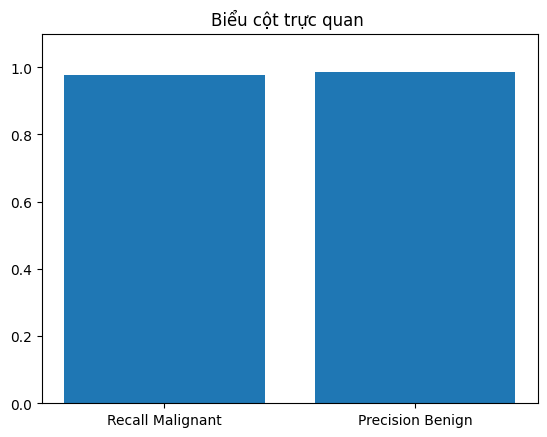

In [25]:
plt.bar(["Recall Malignant", "Precision Benign"], [recall_malignat, precision_bengin])
plt.ylim(0, 1.1)
plt.title("Biểu cột trực quan ")
plt.show()

Mô hình SVM với kernel rbf cho kết quả khá tốt trên bộ dữ liệu Breast Cancer. 
Chỉ số Recall của lớp Malignant đạt khoảng 0.976, cho thấy mô hình phát hiện đúng phần lớn các trường hợp ung thư ác tính. 
Chỉ số Precision của lớp Benign đạt khoảng 0.986, cho thấy khi mô hình dự đoán một mẫu là lành tính thì độ tin cậy khá cao. 
Hai giá trị đều gần bằng 1 nên biểu đồ cột thể hiện kết quả đánh giá tốt của mô hình.